# Retail Sales Data Analysis – Exploratory Data Analysis

## Introduction

This project performs Exploratory Data Analysis (EDA) on a retail sales dataset.
The analysis focuses on sales trends, customer demographics, product categories,
and relationships between numerical variables.

## Objectives

- Understand the structure and quality of the retail sales data.
- Analyze monthly and quarterly sales trends.
- Study customer age groups and gender distribution.
- Identify high-volume transactions.
- Analyze revenue generated by product category.
- Examine relationships between numerical variables.
- Generate business insights and recommendations.

## Dataset Information

The dataset contains 1,000 retail transaction records and 9 columns.

### Main Variables

- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount

The dataset contains no missing values.
The Date column was converted from string format to datetime format
for time-based analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [10]:
print("Mean:")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mean())

print("\nMedian:")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].median())

print("\nMode:")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode().iloc[0])

print("\nStandard Deviation:")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].std())

Mean:
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [11]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

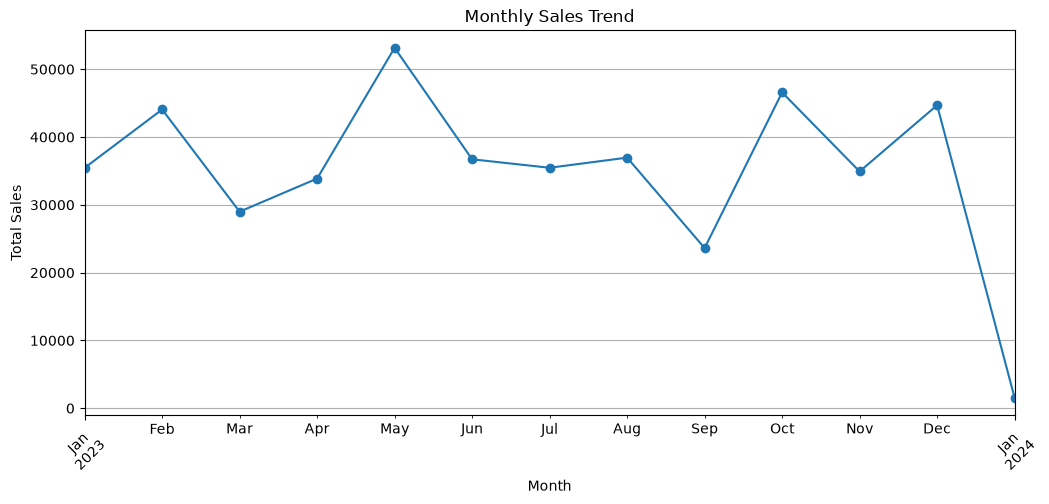

In [12]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation
The monthly sales trend shows how total sales changed over time. 
The months with higher values indicate stronger sales performance, 
while lower values indicate relatively weaker sales periods.

In [13]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

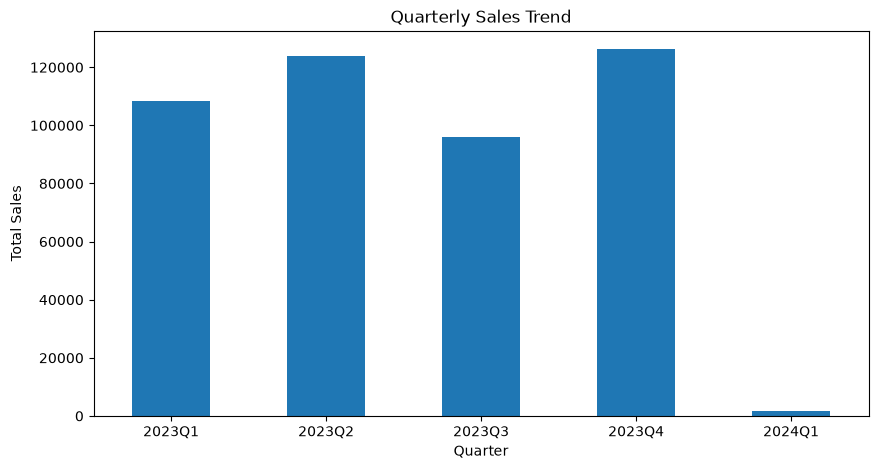

In [14]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='bar')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation
The quarterly sales chart shows the variation in total sales across different quarters.
It helps identify which quarter generated relatively higher or lower sales.

In [15]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Below 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

age_group_counts = df['Age Group'].value_counts().sort_index()

age_group_counts

Age Group
Below 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

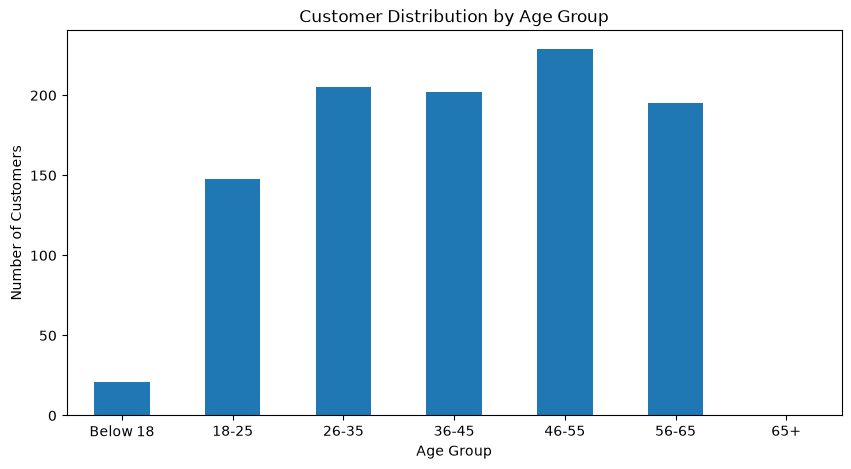

In [16]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation
The age-group distribution shows how customers are distributed across different age ranges.
The most populated age group represents the largest customer segment in the dataset.

In [17]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

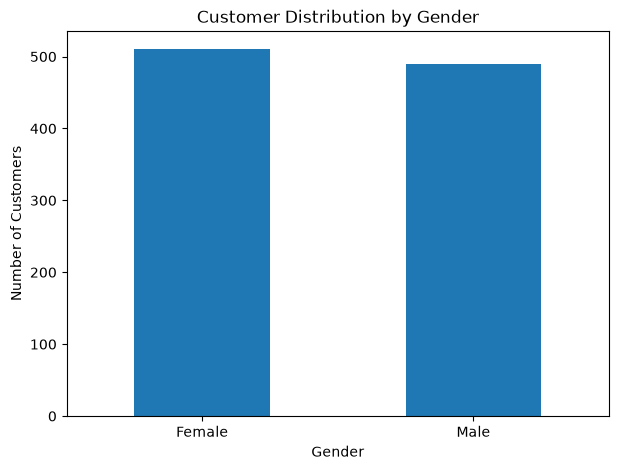

In [18]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation
The gender distribution shows the number of customers belonging to each gender.
This helps understand the gender composition of the customer base.

In [19]:
top_10_sales = df.nlargest(10, 'Quantity')[
    ['Transaction ID', 'Product Category', 'Quantity', 'Total Amount']
]

top_10_sales

,Transaction ID,Product Category,Quantity,Total Amount
7,8,Electronics,4,100
9,10,Clothing,4,200
13,14,Clothing,4,120
14,15,Electronics,4,2000
16,17,Clothing,4,100
22,23,Clothing,4,120
30,31,Electronics,4,1200
37,38,Beauty,4,200
38,39,Clothing,4,120
45,46,Electronics,4,1200


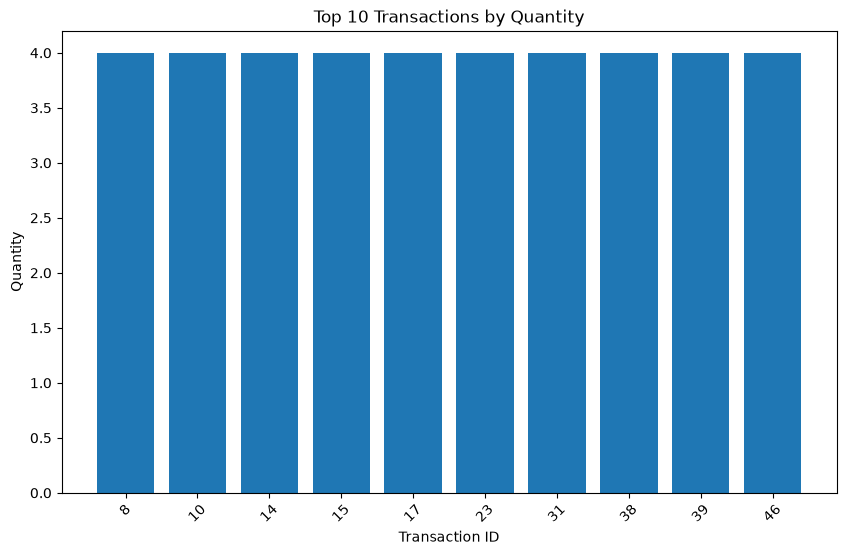

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_sales['Transaction ID'].astype(str),
    top_10_sales['Quantity']
)

plt.title('Top 10 Transactions by Quantity')
plt.xlabel('Transaction ID')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

plt.show()

### Observation
The chart shows the 10 transactions with the highest quantities purchased.
These transactions represent the highest-volume purchases in the dataset.

In [21]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

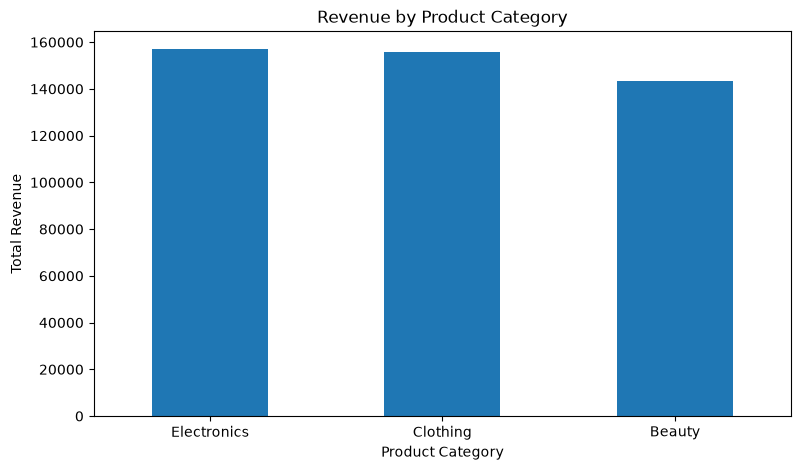

In [22]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

### Observation
The revenue comparison shows the contribution of each product category to total sales.
The category with the highest revenue contributes the most to the overall sales value.

In [23]:
correlation_matrix = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


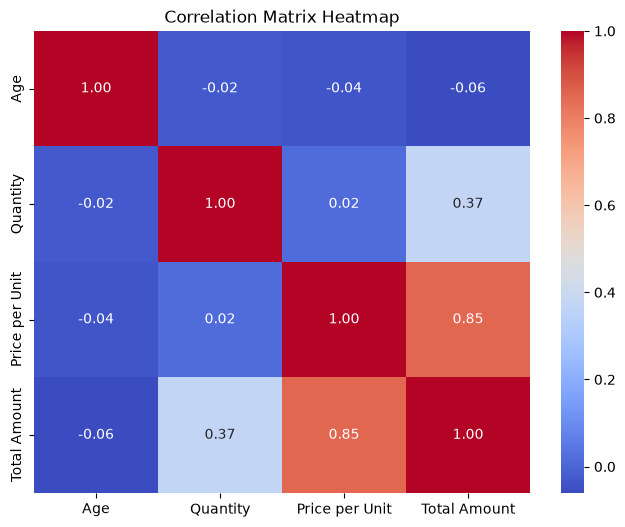

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix Heatmap')
plt.show()

### Observation
The correlation heatmap shows the strength of relationships between numerical variables.
Values closer to +1 indicate a strong positive relationship, while values closer to -1 indicate a negative relationship.
Values close to 0 indicate a weak linear relationship.

In [25]:
category_gender_sales = df.pivot_table(
    values='Total Amount',
    index='Product Category',
    columns='Gender',
    aggfunc='sum'
)

category_gender_sales

Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


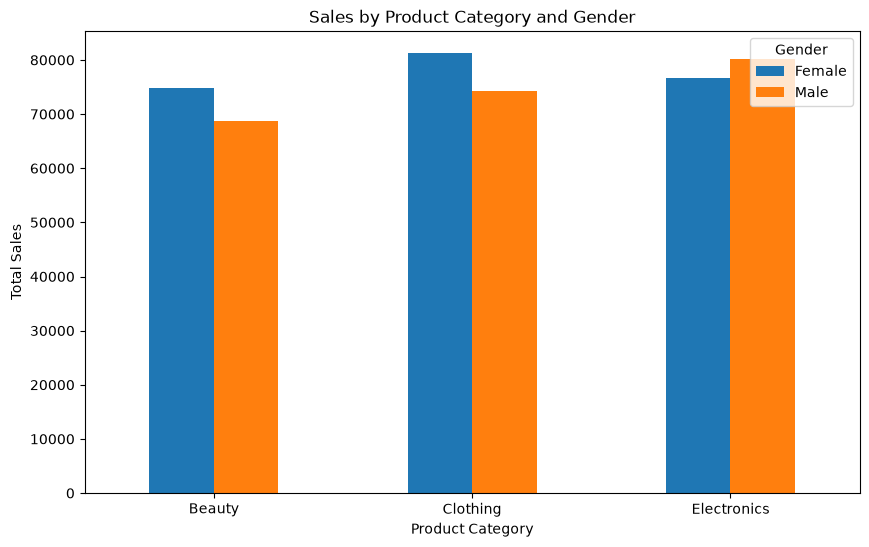

In [26]:
category_gender_sales.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Gender')

plt.show()

### Observation
The chart compares sales across product categories for different genders.
It helps identify whether sales patterns differ between genders across categories.
This comparison can help businesses understand customer segments and category-level purchasing patterns.

## Business Recommendations

1. Focus marketing efforts on the customer age groups that contribute the highest number of transactions.

2. Give greater attention to the product categories generating higher total revenue and analyze their sales patterns for future planning.

3. Use gender-wise and category-wise sales patterns to create more targeted promotions and marketing campaigns.

## Key Findings

- The dataset contains 1,000 transaction records with 9 variables.
- No missing values were found in the dataset.
- Monthly and quarterly analysis shows variation in sales over time.
- Customer transactions can be compared across different age groups and genders.
- Product categories contribute differently to overall revenue.
- The correlation heatmap helps identify relationships among age, quantity,
  price per unit, and total amount.
- Category and gender analysis provides additional insight into customer
  purchasing patterns.

## Conclusion

The exploratory analysis provides an overview of retail sales performance
and customer purchasing patterns. The analysis of time trends, customer
demographics, product categories, and numerical relationships helps identify
areas that can support data-driven business decisions.

The results can be used to improve marketing strategies, understand customer
segments, and focus attention on high-performing product categories.

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook